# Neural Representation Learning - Basic Usage

This notebook demonstrates the basic usage of the Neural Representation Learning package.

## Overview
1. Load and preprocess neural data
2. Train a contrastive learning model
3. Extract embeddings
4. Basic evaluation

**Expected runtime**: 5-10 minutes (GPU) / 20-30 minutes (CPU)

In [1]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import our packages
import sys, os, glob
sys.path.append("/vault/jiaxx/model/neural_repr/")
from neural_repr_package import NeuralRepresentationLearner, Config
from neural_evaluation import NeuralEmbeddingEvaluator, EvaluationConfig

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")

print("📦 Packages imported successfully!")
print(f"🔧 PyTorch version: {torch.__version__}")
print(f"🔧 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔧 GPU: {torch.cuda.get_device_name(0)}")

📦 Packages imported successfully!
🔧 PyTorch version: 2.5.1
🔧 CUDA available: True
🔧 GPU: NVIDIA GeForce RTX 4090


In [16]:
area_bank = {'probeA':'AM',
             'probeB':'PM',
             'probeC': 'V1',
             'probeD': 'LM',
             'probeE': 'AL',
             'probeF': 'RL'
            }

cmap_type = {'nn': "purple",
             'tex': "blue",
            'noise': "deepskyblue",
            'blank': "gray"
            }

region_color_map = {
    "VISp": "#9992C3",
    "VISl": "#7391C0",
    "VISal": "#D5C594",
    "VISrl": "#88C1D3",
    "VISpm": "#E39C78",
    "VISam": "#D17578",
    'V1': "#9992C3",
    'LM': "#7391C0",
    'AL': "#D5C594",
    'RL': "#88C1D3",
    'PM': "#E39C78",
    'AM': "#D17578",
    'probeC': "#9992C3",
    'probeD': "#7391C0",
    'probeE': "#D5C594",
    'probeF': "#88C1D3",
    'probeB': "#E39C78",
    'probeA': "#D17578",
}

## 1. Create or Load Your Data

For this example, we'll create synthetic data that mimics real neural recordings.
**Replace this section with your actual data loading code.**

In [ ]:
def create_synthetic_neural_data():
    """
    Create synthetic neural data for demonstration.
    Replace this with your actual data loading function.
    """
    np.random.seed(42)
    
    # Parameters
    n_neurons = 100
    n_images = 300
    n_trials = 10
    n_timebins = 100  # Remove this line if you have trial-averaged data
    
    print(f"📊 Creating synthetic neural data...")
    print(f"   Neurons: {n_neurons}")
    print(f"   Images: {n_images}")
    print(f"   Trials per image: {n_trials}")
    print(f"   Time bins: {n_timebins}")
    
    # Create temporal neural data (4D: neurons × images × trials × time)
    neural_data = np.random.poisson(0.15, (n_neurons, n_images, n_trials, n_timebins))
    
    # Add structured responses based on image categories
    n_categories = 6
    images_per_category = n_images // n_categories
    
    for cat_idx in range(n_categories):
        start_img = cat_idx * images_per_category
        end_img = start_img + images_per_category
        
        # Category-specific neurons (first 20 neurons respond to specific categories)
        responsive_neurons = slice(cat_idx * 15, (cat_idx + 1) * 15)
        
        # Add category-specific response with temporal dynamics
        peak_time = 30 + cat_idx * 5  # Different peak times
        temporal_kernel = np.exp(-0.5 * ((np.arange(n_timebins) - peak_time) / 8) ** 2)
        
        category_response = 0.3 * temporal_kernel[np.newaxis, np.newaxis, :]
        neural_data[responsive_neurons, start_img:end_img, :, :] += category_response
    
    # Ensure non-negative
    neural_data = np.maximum(0, neural_data)
    
    return neural_data

def create_stimulus_table(n_images=300):
    """
    Create stimulus table for demonstration.
    Replace this with your actual stimulus table.
    """
    np.random.seed(42)
    
    # Define stimulus categories
    stim_types = ['natural_images', 'textures', 'noise']
    categories = {
        'natural_images': ['animals', 'objects', 'scenes'],
        'textures': ['rough', 'smooth'],
        'noise': ['white']
    }
    
    stim_data = []
    
    for img_idx in range(n_images):
        # Assign stimulus type and category
        stim_type = stim_types[img_idx % len(stim_types)]
        available_cats = categories[stim_type]
        category = available_cats[(img_idx // len(stim_types)) % len(available_cats)]
        
        stim_data.append({
            'stim_type': stim_type,
            'category': category,
            'unique_img': f'img_{img_idx:03d}.jpg',
            'block': (img_idx // 50) + 1,  # 6 blocks
            'presentation_order': img_idx,
            'duration': 0.25
        })
    
    return pd.DataFrame(stim_data)

# Create synthetic data
neural_data = create_synthetic_neural_data()
stim_table = create_stimulus_table(neural_data.shape[1])

print(f"\n✅ Data created:")
print(f"   Neural data shape: {neural_data.shape}")
print(f"   Stimulus table shape: {stim_table.shape}")
print(f"\n📋 Stimulus categories:")
print(stim_table.groupby(['stim_type', 'category']).size())

In [2]:
neural_data = np.load('/vault/jiaxx/decipher_variability/processed_data/gold/sc_2Hz_image_probeC.npy')
df = pd.read_csv('/vault/jiaxx/decipher_variability/processed_data/gold/sc_2Hz_image_probeC.csv')
stim_table = pd.read_csv('/vault/jiaxx/decipher_variability/processed_data/gold/stim_table_unique_all_repeatedblank.csv', index_col=0)


## 2. Configure the Model

Set up the configuration for training. Adjust these parameters based on your needs.

In [3]:
# Configure the model
config = Config(
    # Model architecture
    hidden_dims=[128, 64],           # Hidden layer sizes
    embedding_dim=32,                # Final embedding dimension
    activation='relu',               # Activation function
    dropout=0.1,                     # Dropout rate
    
    # Training parameters
    batch_size=512,                   # Batch size (reduce if memory issues)
    learning_rate=1e-3,              # Learning rate
    weight_decay=1e-4,               # L2 regularization
    temperature=0.1,                 # Contrastive learning temperature
    
    # Data preprocessing
    bin_size=10,                     # Temporal binning (ms)
    smoothing_sigma=0,             # Gaussian smoothing
    
    # Sampling
    balanced_sampling=True,          # Balance categories in batches
    
    # Hardware
    cuda_id=0 if torch.cuda.is_available() else None  # Use GPU if available
)

print("⚙️ Model configuration:")
print(f"   Embedding dimension: {config.embedding_dim}")
print(f"   Hidden layers: {config.hidden_dims}")
print(f"   Batch size: {config.batch_size}")
print(f"   Device: {'GPU' if config.cuda_id is not None else 'CPU'}")
print(f"   Balanced sampling: {config.balanced_sampling}")

⚙️ Model configuration:
   Embedding dimension: 32
   Hidden layers: [128, 64]
   Batch size: 512
   Device: GPU
   Balanced sampling: True


## 3. Create Datasets and Train Model

This section creates train/test datasets and trains the contrastive learning model.

In [4]:
# Initialize the learner
learner = NeuralRepresentationLearner(config)

# Create datasets from stimulus table
print("🔄 Creating datasets...")
train_dataset, test_dataset, conversion_info = learner.create_datasets_from_stim_table(
    neural_data, 
    stim_table, 
    test_size=0.2
)

print(f"\n📊 Dataset info:")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Test samples: {len(test_dataset)}")
stimulus_types = conversion_info['category_mappings'].keys()
print(f"   Stimulus types: {stimulus_types}")

cat_all = []
for s in stimulus_types:
    cat = np.unique(list(conversion_info['category_mappings'][s].values()))
    cat_all.append(cat)
cat_all = np.concatenate(cat_all)
n_total_categories = len(np.unique(cat_all))
print(f"   Categories: {n_total_categories}")


# Create data loaders
train_loader = learner.create_dataloader(train_dataset, shuffle=True)
test_loader = learner.create_dataloader(test_dataset, shuffle=False)

print(f"\n📦 Data loaders created with batch size: {config.batch_size}")

🔧 Using GPU: cuda:0 (NVIDIA GeForce RTX 4090)
🔄 Creating datasets...
🔄 Converting stimulus table and creating datasets...
📋 Auto-detected columns: category='category', exemplar='unique_img', stim_type='stim_type'
   Block column: 'stimulus_block'
📊 Split: 799 train, 200 test images
📊 train dataset: 799 samples
   Categories: 38 unique
📊 test dataset: 200 samples
   Categories: 38 unique

📊 Dataset info:
   Training samples: 799
   Test samples: 200
   Stimulus types: dict_keys(['blank', 'nn', 'noise', 'tex'])
   Categories: 23

📦 Data loaders created with batch size: 512


In [5]:
# Initialize the model
input_dim = neural_data.shape[0]  # Number of neurons
learner.initialize_model(input_dim)

print(f"🔧 Model initialized:")
print(f"   Input dimension: {input_dim} neurons")
print(f"   Output dimension: {config.embedding_dim}")

# Count parameters
total_params = sum(p.numel() for p in learner.model.parameters())
trainable_params = sum(p.numel() for p in learner.model.parameters() if p.requires_grad)
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

🔧 Model initialized with 173920 parameters
🔧 Model initialized:
   Input dimension: 1277 neurons
   Output dimension: 32
   Total parameters: 173,920
   Trainable parameters: 173,920


In [6]:
# Train the model
print("🏋️ Starting training...")

num_epochs = 100  # Adjust based on your needs
train_losses = []

for epoch in range(num_epochs):
    # Train for one epoch
    loss = learner.train_epoch(train_loader)
    train_losses.append(loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"   Epoch {epoch+1:2d}/{num_epochs}: Loss = {loss:.4f}")

print(f"\n✅ Training completed!")
print(f"   Final loss: {train_losses[-1]:.4f}")
print(f"   Loss reduction: {train_losses[0]:.4f} → {train_losses[-1]:.4f}")

🏋️ Starting training...
   Epoch  1/100: Loss = 3.4203
   Epoch  5/100: Loss = 2.3586
   Epoch 10/100: Loss = 1.7061
   Epoch 15/100: Loss = 1.3592
   Epoch 20/100: Loss = 1.0610
   Epoch 25/100: Loss = 0.8996
   Epoch 30/100: Loss = 0.7869
   Epoch 35/100: Loss = 0.7300
   Epoch 40/100: Loss = 0.6830
   Epoch 45/100: Loss = 0.5582
   Epoch 50/100: Loss = 0.5008
   Epoch 55/100: Loss = 0.5241
   Epoch 60/100: Loss = 0.4846
   Epoch 65/100: Loss = 0.5091
   Epoch 70/100: Loss = 0.4184
   Epoch 75/100: Loss = 0.4030
   Epoch 80/100: Loss = 0.3836
   Epoch 85/100: Loss = 0.3510
   Epoch 90/100: Loss = 0.3619
   Epoch 95/100: Loss = 0.3421
   Epoch 100/100: Loss = 0.3304

✅ Training completed!
   Final loss: 0.3304
   Loss reduction: 3.4203 → 0.3304


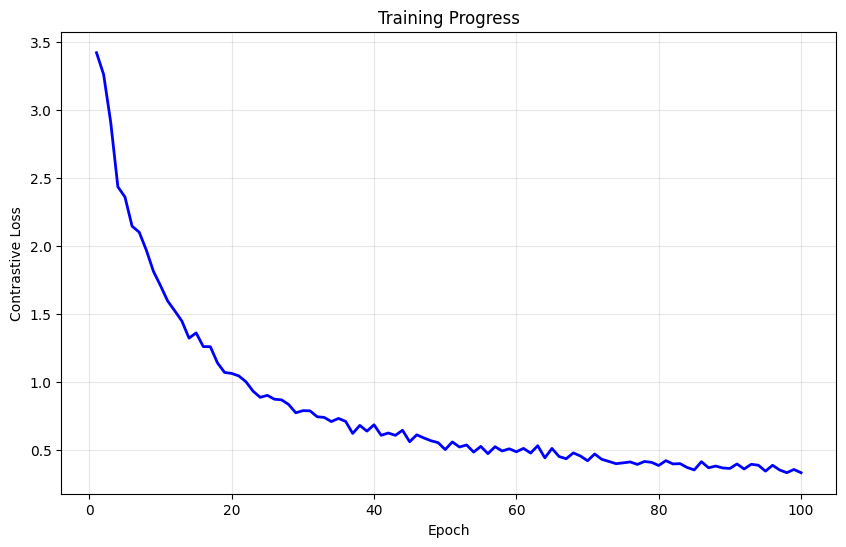

📈 Training curve plotted - loss decreased from 3.4203 to 0.3304


In [7]:
# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Training Progress')
plt.grid(True, alpha=0.3)
plt.show()

print(f"📈 Training curve plotted - loss decreased from {train_losses[0]:.4f} to {train_losses[-1]:.4f}")

## 4. Extract Embeddings

Extract embeddings from the trained model for analysis.

In [8]:
# Extract embeddings from test set
print("🔍 Extracting embeddings...")

embeddings, categories, metadata = learner.extract_embeddings(test_loader)

print(f"\n📊 Embeddings extracted:")
print(f"   Shape: {embeddings.shape}")
print(f"   Categories: {len(set(categories))} unique")
print(f"   Samples: {len(embeddings)}")

# Show category distribution
category_counts = pd.Series(categories).value_counts()
print(f"\n📋 Category distribution:")
for cat, count in category_counts.items():
    print(f"   {cat}: {count} samples")

🔍 Extracting embeddings...

📊 Embeddings extracted:
   Shape: (200, 32)
   Categories: 38 unique
   Samples: 200

📋 Category distribution:
   nn_hamster: 18 samples
   nn_bird: 18 samples
   nn_mouse: 18 samples
   nn_mushroom: 18 samples
   nn_cat: 18 samples
   nn_flower: 12 samples
   nn_snake: 6 samples
   noise_im38: 3 samples
   noise_im56: 3 samples
   noise_im52: 3 samples
   blank_blank: 3 samples
   tex_im48: 3 samples
   tex_im99: 3 samples
   tex_im336: 3 samples
   noise_im13: 3 samples
   noise_im393: 3 samples
   noise_im71: 3 samples
   noise_im99: 3 samples
   tex_im38: 3 samples
   tex_im402: 3 samples
   tex_im60: 3 samples
   tex_im71: 3 samples
   noise_im336: 3 samples
   noise_im23: 3 samples
   tex_im56: 3 samples
   noise_im402: 3 samples
   noise_im60: 3 samples
   tex_im18: 3 samples
   noise_im48: 3 samples
   tex_im393: 3 samples
   tex_im30: 3 samples
   noise_im18: 3 samples
   tex_im327: 3 samples
   tex_im23: 3 samples
   noise_im30: 3 samples
   tex_im

## 5. Basic Evaluation

Evaluate the quality of learned embeddings using clustering and classification metrics.

In [9]:
# Configure evaluation
eval_config = EvaluationConfig(
    n_clusters_range=(2, 15),
    cv_folds=5,
    figsize=(12, 8),
    save_plots=False  # Set to True to save plots
)

# Initialize evaluator
evaluator = NeuralEmbeddingEvaluator(eval_config)

print("📊 Running comprehensive evaluation...")

# Run full evaluation
results = evaluator.evaluate_all(
    embeddings, 
    categories, 
    metadata,
    save_dir=None  # Set to "results/basic_evaluation" to save plots
)

print("\n✅ Evaluation completed!")

📊 Running comprehensive evaluation...
🚀 Running comprehensive embedding evaluation...
   Embeddings shape: (200, 32)
   Unique categories: 38
   Total samples: 200

🔍 Evaluating clustering quality...
   Testing k=2...
   Testing k=3...
   Testing k=4...
   Testing k=5...
   Testing k=6...
   Testing k=7...
   Testing k=8...
   Testing k=9...
   Testing k=10...
   Testing k=11...
   Testing k=12...
   Testing k=13...
   Testing k=14...
   Testing k=15...
   Best k: 4 (silhouette: 0.268)

🔍 Evaluating linear probing performance...
   Evaluating primary classification...
      Best classifier: logistic (CV accuracy: 0.490 ± 0.025)

🔍 Computing Representational Similarity Analysis...
   Computing euclidean distances...
   Computing cosine distances...

🎨 Generating visualizations...

✅ Comprehensive evaluation completed!

✅ Evaluation completed!


In [10]:
# Print summary report
evaluator.print_summary_report(results)


📊 EVALUATION SUMMARY REPORT
📋 Dataset Info:
   Samples: 200
   Embedding Dimension: 32
   Categories: 38

🎯 Clustering Performance:
   Best Silhouette Score: 0.268
   Optimal k: 4
   True k: 38

🎯 Linear Probing Performance:
   Primary_labels:
     Best Classifier: logistic
     CV Accuracy: 0.490 ± 0.025
     F1 Score: 0.727

🎯 Representational Similarity:
   Euclidean Distance:
     primary_labels: r = 0.235
   Cosine Distance:
     primary_labels: r = 0.267



## 6. Visualize Results

Create visualizations to understand the learned embedding space.

In [15]:
# project all data to embedding space:
from neural_repr_package import NeuralDataset, DataLoader, smart_convert
metadata_list, image_to_category_all, category_mappings_all = smart_convert(stim_table)

full_dataset = NeuralDataset(
        neural_data, 
        metadata_list, 
        learner.config, 
        mode='test'  # Use test mode to avoid augmentation
    )

full_loader = DataLoader(
        full_dataset,
        batch_size=learner.config.batch_size,
        shuffle=False,  # Keep original order
        drop_last=False  # Include all samples
    )

embeddings_all, categories_all, metadata_all = learner.extract_embeddings(full_loader)



📋 Auto-detected columns: category='category', exemplar='unique_img', stim_type='stim_type'
   Block column: 'stimulus_block'
📊 test dataset: 999 samples
   Categories: 38 unique


In [13]:
embeddings_all.shape

(999, 32)

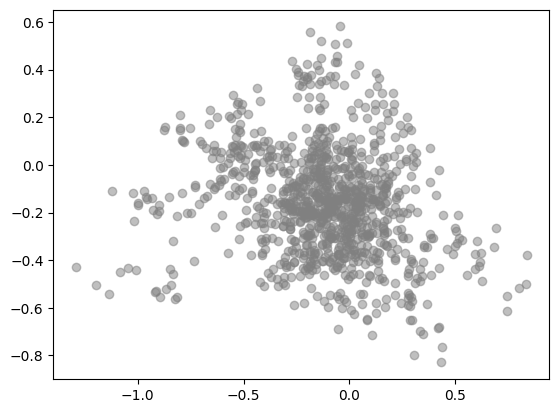

In [56]:
plt.scatter(embeddings_all[:, 0], embeddings_all[:, 1], alpha=0.5, c = 'gray')

In [57]:
from sklearn.manifold import TSNE

# tex_idx = stim_table_unique_all.stim_type=='tex'
# X_noise = tmp[:,noise_idx,50:150].sum(-1)/0.1
X = embeddings_all
model = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=30)
X_embedded = model.fit_transform(X)
# X_embedded_tex = X_embedded[:X_tex.shape[1],:]
# X_embedded_noise = X_embedded[X_tex.shape[1]:,:]

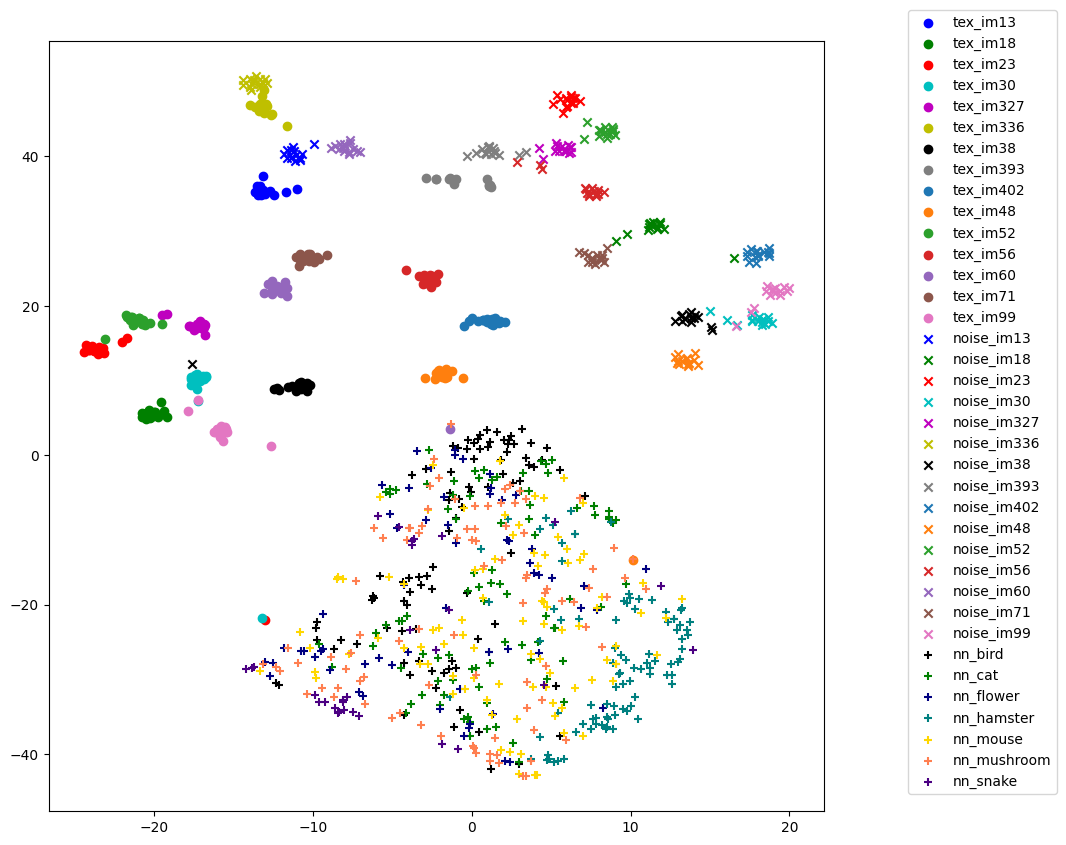

In [58]:
plt.figure(figsize=(10,10))
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:gray', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
all_cat = np.unique(categories_all)
ni_cat = [cat for cat in all_cat if 'nn' in cat]
tex_cat = [cat for cat in all_cat if 'tex' in cat]
noise_cat = [cat for cat in all_cat if 'noise' in cat]

for idx, nn_type in enumerate(tex_cat):
    nn_idx = [idx for idx, cat in enumerate(categories_all) if cat==nn_type] 
    plt.scatter(X_embedded[nn_idx,0], X_embedded[nn_idx,1], label=nn_type, c=colors[idx])

for idx, nn_type in enumerate(noise_cat):
    nn_idx = [idx for idx, cat in enumerate(categories_all) if cat==nn_type] 
    plt.scatter(X_embedded[nn_idx,0], X_embedded[nn_idx,1], label=nn_type, marker='x', c=colors[idx])


colors_nn = ['black', 'green', 'navy', 'teal', 'gold', 'coral', 'indigo']
for idx, nn_type in enumerate(ni_cat):
    nn_idx = [idx for idx, cat in enumerate(categories_all) if cat==nn_type] 
    plt.scatter(X_embedded[nn_idx,0], X_embedded[nn_idx,1], label=nn_type, marker='+', c=colors_nn[idx])

#plt.xlim([-60,40])
#plt.ylim([-60,40])
plt.legend(bbox_to_anchor=(1.1, 1.05))

In [55]:


# Create hierarchical visualization
print("\n🎨 Creating hierarchical visualization...")

evaluator.visualizer.plot_hierarchical_embedding(
    embeddings, 
    metadata,
    hierarchy_keys=['image_type', 'category']
)


🎨 Creating hierarchical visualization...
No hierarchical keys found in metadata


## 7. Save Results (Optional)

Save the trained model and embeddings for later analysis.

In [ ]:
# Create results directory
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

# Save model
model_path = results_dir / "basic_model.pth"
learner.save_model(str(model_path))

# Save embeddings
embeddings_path = results_dir / "basic_embeddings.npz"
np.savez(
    embeddings_path,
    embeddings=embeddings,
    categories=categories,
    metadata=metadata
)

# Save evaluation results
import pickle
results_path = results_dir / "basic_evaluation_results.pkl"
with open(results_path, 'wb') as f:
    pickle.dump(results, f)

print(f"💾 Results saved to {results_dir}:")
print(f"   Model: {model_path}")
print(f"   Embeddings: {embeddings_path}")
print(f"   Evaluation: {results_path}")

## 🎯 Key Results Summary

Let's extract the key metrics from our analysis:

In [59]:
# Extract key metrics
summary = results['evaluation_summary']

print("🎯 KEY RESULTS SUMMARY")
print("=" * 50)

# Clustering performance
if 'clustering' in summary:
    clustering = summary['clustering']
    print(f"🎯 CLUSTERING QUALITY:")
    print(f"   Best Silhouette Score: {clustering.get('best_silhouette_score', 0):.3f}")
    print(f"   Optimal k: {clustering.get('best_k', 'N/A')}")
    print(f"   True k: {clustering.get('n_true_clusters', 'N/A')}")
    
    if 'true_k_performance' in clustering:
        true_k = clustering['true_k_performance']
        print(f"   ARI (true k): {true_k.get('adjusted_rand_score', 0):.3f}")
        print(f"   NMI (true k): {true_k.get('normalized_mutual_info', 0):.3f}")

# Linear probing performance
if 'linear_probing' in summary:
    lp = summary['linear_probing']
    print(f"\n🎯 CLASSIFICATION PERFORMANCE:")
    
    for task, task_summary in lp.items():
        print(f"   {task.replace('_', ' ').title()}:")
        print(f"     CV Accuracy: {task_summary.get('cv_accuracy', 0):.1f}%")
        print(f"     F1 Score: {task_summary.get('f1_score', 0):.3f}")
        print(f"     Best Classifier: {task_summary.get('best_classifier', 'N/A')}")

print(f"\n📊 INTERPRETATION:")
print(f"   - Higher silhouette scores (>0.5) indicate well-separated clusters")
print(f"   - ARI/NMI scores (>0.7) suggest good alignment with true categories")
print(f"   - Classification accuracy (>80%) indicates separable representations")
print(f"   - These metrics will be compared across brain regions")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Run this analysis on multiple brain regions (V1, V2, V4)")
print(f"   2. Use cross-region comparison notebook")
print(f"   3. Compare clustering quality across the visual hierarchy")
print(f"   4. Analyze whether higher areas show better category separation")

🎯 KEY RESULTS SUMMARY
🎯 CLUSTERING QUALITY:
   Best Silhouette Score: 0.268
   Optimal k: 4
   True k: 38

🎯 CLASSIFICATION PERFORMANCE:
   Primary Labels:
     CV Accuracy: 0.5%
     F1 Score: 0.727
     Best Classifier: logistic

📊 INTERPRETATION:
   - Higher silhouette scores (>0.5) indicate well-separated clusters
   - ARI/NMI scores (>0.7) suggest good alignment with true categories
   - Classification accuracy (>80%) indicates separable representations
   - These metrics will be compared across brain regions

🚀 NEXT STEPS:
   1. Run this analysis on multiple brain regions (V1, V2, V4)
   2. Use cross-region comparison notebook
   3. Compare clustering quality across the visual hierarchy
   4. Analyze whether higher areas show better category separation


## 🎉 Congratulations!

You've successfully:
- ✅ Loaded and preprocessed neural data
- ✅ Trained a contrastive representation learning model
- ✅ Extracted meaningful embeddings
- ✅ Evaluated clustering and classification performance
- ✅ Visualized the learned embedding space

### Next Steps:
1. **Apply to your real data**: Replace the synthetic data with your actual neural recordings
2. **Cross-region comparison**: Use notebook `02_cross_region_comparison.ipynb`
3. **Advanced analysis**: Explore `03_advanced_evaluation.ipynb`
4. **Hyperparameter tuning**: Experiment with different model configurations

### Tips for Real Data:
- Start with smaller datasets to validate the pipeline
- Adjust `batch_size` and `learning_rate` based on your data size
- Use GPU acceleration for faster training
- Save intermediate results for reproducibility